# b-Chromatic Coloring

A $b$-chromatic number parameter for a graph $G$ is the maximum number of colors for which $G$ has a proper colouring such that every colour contains a vertex adjacent to a vertex of every other colour.

# Importing necesary packages

In [1]:
import sys
sys.version

'3.10.4 (main, Mar 31 2022, 03:37:37) [Clang 12.0.0 ]'

In [2]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

# Utility functions

__Definition of $m$ degree__: For a graph $G=(V,E)$, supposed that the vertices of $G$ are ordered $v_1, v_2, \dots, v_n$ such that $d(v_1)\geq d(v_2) \geq \dots \geq d(v_n)$. Then the $m$-degree, $m(G)$, of $G$ is defined
$$
m(G)=\max \{1\leq i \leq n: d(v_i)\geq i-1\}.
$$

Generating a random tree

1. We will generate a n-lenght list of random integers between 1 and some integer k
2. At every step we will choose an element of the list and decrease it by 1 until the total sum of all elements in the list has a value of $2(n-1)$

__First method: Generating random trees with BFS__

In [245]:
def build_random_tree_nodes(n):   
    import random
    if n == 1: return {0:0}
    degrees_sum = 0
    nodes_degree = {i:random.randint(1, n) for i in range(n)}
    #print(nodes_degree)
    aux = nodes_degree.copy()
    for i in range(n): degrees_sum += nodes_degree[i]
    difference = degrees_sum - 2*(n-1)
    #print(difference)
    while(difference < 0):
        key = random.choice(list(nodes_degree.keys()))
        nodes_degree[key] += 1
        difference += 1
    #now we decrease the degree of random nodes one by one until we get a proper tree
    for i in range(n): 
        if aux[i]==1: aux.pop(i)
    while(difference > 0):
        key = random.choice(list(aux.keys()))
        aux[key] -= 1
        nodes_degree[key] -= 1
        if aux[key] == 1: aux.pop(key)
        difference -= 1
    assert 2*(n-1) == sum(list(nodes_degree.values()))
    nodes_degree = dict(sorted(nodes_degree.items(), key = lambda item: item[1], reverse=True))
    return nodes_degree

In [81]:
def random_bfs_tree(n):
    nodes_degree = build_random_tree_nodes(n)
    if len(nodes_degree) == 1: 
        T =  nx.Graph()
        T.add_node(list(nodes_degree.keys())[0])
        return T
    number_neighbours = nodes_degree.copy()
    nodes = list(nodes_degree.keys())
    i = 0
    w = nodes[i]
    i += 1
    edge_list = []
    Q = [w]
    while len(Q) != 0:
        u = Q.pop(0)
        for _ in range(number_neighbours[u]):
            v = nodes[i]
            #print(i, (u, v))
            edge_list.append((u, v))
            Q.append(v)
            number_neighbours[v] -= 1
            i += 1
    T = nx.Graph(edge_list)
    
    return T

__Second method: Generating random trees recursively__

In [5]:
def random_recursive_tree(n):
    nodes = [0]
    edge_list = []
    for v in range(1, n):
        u = random.choice(nodes)
        edge_list.append((u, v))
        nodes.append(v)
    return nx.Graph(edge_list)

__Third method: Generating random trees with MST__

In [6]:
def random_mst_tree(n):
    G = nx.complete_graph(n)
    for u, v in G.edges():
        G[u][v]['weight'] = random.random()
    T = nx.minimum_spanning_tree(G)
    return T

In [7]:
def get_m_degree(T):
    X = [0 for _ in range(0, len(T.nodes())+1)]
    Z = [0 for _ in range(0, len(T.nodes())+1)]
    max_j = 0
    for u in T.nodes(): X[T.degree(u)] += 1
    for j in range(len(T.nodes())-1, 0, -1): Z[j] = Z[j+1] + X[j]
    for j in range(1, len(T.nodes)):
        if Z[j-1] >= j:
            max_j = j
    return max_j

In [8]:
def get_m_degree_2(T):
    vertex_degree_list = {u:T.degree(u) for u in T.nodes()}
    sorted_vertex_set = dict(sorted(vertex_degree_list.items(), key=lambda item:item[1], reverse=True))
    m = 0
    for i, di in enumerate(sorted_vertex_set.values()):
        if (di >= i): m = i + 1
    return m

__Definition of dense vertices__: Let $T=(V,E)$ be a tree. Let us call a vertex $v$ of $T$ sucht that $d(v)\geq m-1$ a dense vertex of $T$.

In [9]:
def get_dense_vertices(T, m):
    dense_vertices = []
    for u in T.nodes():
        if T.degree(u) >= m-1: dense_vertices.append(u)
    return dense_vertices

In [10]:
def get_random_color():
    import random
    hexadecimal = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])][0]
    return hexadecimal

Function to get the colors for coloring the drawing of the graph

In [11]:
def get_colors_to_use(T, colors, n):
    unique_colors = set(list(colors.values()))
    colors_to_use = {c:get_random_color() for c in unique_colors if c is not None}
    node_colors_list = []
    for u in colors.keys():
        if colors[u] is not None:
            node_colors_list.append(colors_to_use[colors[u]])
        else:
            node_colors_list.append('#FFFFFF')
    return node_colors_list

Function to check where a coloring of $T$ is $b$-chromatic:

1. First, we check if all nodes have colors
2. Then if every good vertex have $m-1$ colors adjacent to it
3. At the end we check if every pair of vertices share the same color

In [12]:
def check_b_chromatic_coloring(T, W, colors, m):
    for value in colors.values(): assert value != None
    available_good_colors = {w:set(list(colors.values())) for w in W}
    for w in W:
        available_good_colors[w].discard(colors[w])
        for v in T.adj[w]:
            available_good_colors[w].discard(colors[v])
    for w in W: assert len(available_good_colors[w]) == 0

    for u, v in T.edges(): assert colors[u] != colors[v]

# Coloring a pivoted Tree

1. First, we test if a given tree is pivoted
2. Second, we color the tree with $m-1$ colors

__Definition of pivoted trees:__ A tree $T=(V,E)$ is _pivoted_ if $T$ has exactly $m$ dense vertices, and $T$ contains a distinguished vertex $v$ such that:
1. $v$ is not dense,
2. Each dense vertex is adjacent to either $v$ or to a dense vertex adjacent to $v$ and
3. Any dense vertex adjacent to $v$ and to another dense vertex has degree $m-1$

Checking if a tree $T$ is pivoted in linear time in the number of nodes.

In [252]:
def is_pivoted(T, dense_vertices, m):
    if len(dense_vertices) > m: return False
    H = nx.induced_subgraph(T, dense_vertices)
    CC = list(nx.connected_components(H))
    if len(CC) < 2: return False
    Ts = []
    for cc in CC:
        #print("Connected component: {}".format(cc))
        #if Ti is not an isolated vertex and Ti is not K2
        #print(" Checking if Ti is not an isolated vertex or K2")
        if len(cc) != 1 and len(cc)!=2:
            c = 0
            #print(" Checking if Ti does not contain an unique vertex with degree greater than 1")
            for v in cc:
                if H.degree[v] > 1:
                    #print("  {}".format(H.degree[v]))
                    c += 1
            if c > 1: return False
        Ts.append(cc)
    #print(len(Ts))
    #If we had a star we will just pick its center because is the only that can be connected to the pivot
    if len(Ts[0]) > 2:
        T1 = [w for w in Ts[0] if H.degree[w] > 1]
        T2 = Ts[1]
    if len(Ts[1]) > 2:
        T1 = [w for w in Ts[1] if H.degree[w] > 1]
        T2 = Ts[0]
    else:
        T1 = Ts[0]
        T2 = Ts[1]
        
    #constant foor loop becasue the connected components are at most K2 or the center of the star
    #we will have at most 4 inspections for m-1 vertices so the complexity is O(m)
    pivot = None
    for u in T1:
        for v in T2:
            for w in T.adj[v]:
                if w in T.adj[u]:
                    pivot = w
                    break
    
    #print(pivot)
    if pivot is None: return False
    #after getting the pivot we should verify properties 2 and 3 from definition of the pivot
    
    dist_vertices = {v:-1 for v in T.nodes()}
    dense_mask = {v:False for v in T.nodes()}
    for v in dense_vertices: dense_mask[v]=True
    
    #property 2: each dense vertex is adjacent either to v or to a dense vertex adjancent to v
    #run a BFS to verify if v is found at some point
    #property 3: Any dense vertex adjacent to v and to another dense vertex has degree m-1
    #during the BFS we are going to ask each vertex 2-distance from the pivot if its father has degree m-1
    q = [pivot]
    dist_vertices[pivot] = 0
    while len(q)!=0:
        v=q.pop(0)
        for u in T.adj[v]:
            if dist_vertices[u]==-1:
                dist_vertices[u] = dist_vertices[v]+1
                q.append(u)
                if dense_mask[u]:
                    if dist_vertices[u]>2:
                        return False
                    if dist_vertices[u]==2 and T.degree[v] < m-1:
                        return False
                
    return pivot

If a tree $T$ is pivoted we procceed to color it. We use a function to exchange the first two vertices of $V'$ so that they meet the requirement of __Theorem 3.6.5__. This function is called _get_candidates_v1v2_

In [253]:
def get_candidates_v1_v2(T, V1, v, v1, v2):
    candidates = {u:False for u in V1}
    dist_v = {u:-1 for u in T.nodes()}
    dense = {u:False for u in T.nodes}
    for u in V1: dense[u]=True
    dist_v[v] = 0
    q = [v]
    while len(q) != 0:
        u = q.pop(0)
        for w in T.adj[u]:
            if dist_v[w] == -1 and dense[w]:
                q.append(w)
                dist_v[w] = dist_v[u] + 1
                if dist_v[w] == 2: candidates[u]=True
                
    #print(candidates)
                
    if not candidates[v1]:
        for i, w in enumerate(V1[2:]):
            if candidates[w]:
                V1[0] = w
                V1[i+2] = v1
                
    if not candidates[v2]:
        for i, w in enumerate(V1[2:]):
            if candidates[w]:
                V1[1] = w
                V1[i+2] = v2
    
    return V1

We also use a function to compute the remaining colors that each dense vertex need to use.

In [254]:
def compute_remaining_colors(T, V1, colors, m):
    remaining_colors = {i:i+2 for i in range(m-1)}
    dense_remaining_colors = {u:remaining_colors.copy() for u in V1}
    for u in V1:
        dense_remaining_colors[u].pop(colors[u]-2)
        if u != V1[0]:
            for v in T.adj[u]:
                if colors[v] is not None:
                    dense_remaining_colors[u].pop(colors[v]-2)
    return dense_remaining_colors

Function to color a pivoted tree

In [255]:
def color_pivoted_tree(T, V1, v, m):
    colors = {u:None for u in T.nodes()}
    dense = {u:False for u in T.nodes()}
    for u in V1: dense[u]=True
    V1 = get_candidates_v1_v2(T, V1, v, V1[0], V1[1])
    
    #we search vr adjacent to v1 s.t. vr is dense
    vr = None
    v1 = V1[0]
    for w in T.adj[v1]:
        if dense[w]:
            vr = w
            break
    #we now color v2...vm
    for i, u in enumerate(V1):
        if i > 0:
            colors[u] = i+1
            
    #we assign to the pivot the color of vr
    colors[v] = colors[vr]
    
    #and to v1 the color 2
    colors[v1] = 2
    
    #print(colors)
    
    available_colors = set(list(colors.values()))
    dense_remaining_colors = compute_remaining_colors(T, V1, colors, available_colors)
    #print(dense_remaining_colors)
    
    for u in V1:
        for v in T.adj[u]:
            if colors[v] is None and len(dense_remaining_colors[u]) != 0:
                colors[v] = dense_remaining_colors[u].pop()
    
    non_colored_nodes = [v for v in T.nodes() if colors[v] is None]
    non_colored_nodes_available_colors = compute_remaining_colors(T, non_colored_nodes, colors, available_colors)
    for v in non_colored_nodes:
        colors[v] = non_colored_nodes_available_colors[v].pop()
    
    return colors

# Coloring a non pivoted tree
A non pivoted tree is just a general tree. Given $m(G)$ a general tree have a $b$-chromatic coloring with $m(G)$ colors. A concept close to _pivoted_ vertex is the _encircled_ vertex.

__Definition of encircled vertex__: Let $T=(V,E)$ be a tree, and let $V'$ be the set of dense vertices of $T$. Suppose that $V''$ is a subset of cardinality $m$. Then $V''$ _encircles_ some vertex $v\in V-V''$ if:
1. Each vertex in $V''$ is adjacent to either $v$ or to some vertex in $V''$ adjacent to $v$.
2. Any vertex in $V''$ adjacent to $v$ and to another vertex in $V''$ has degree $m-1$
The vertex $v$ is called an _encircled vertex_ by $V''$.

In [256]:
def does_encircle(T, V2, m):
    #T is the tree
    #V_2 is the subset of dense vertices
    #Return the encircle vertex if exists; None otherwise
    assert len(V2) == m
    
    H = nx.subgraph(T, V2)
    CC = nx.connected_components(H)
    Ts = [cc for cc in CC]
    
    if len(Ts)<2: return False
    
    T1 = Ts[0]
    T2 = Ts[1]
    
    #If we had a star we will just pick its center because is the only that can be connected to the pivot
    if len(T1) > 2:
        T1 = [w for w in T1 if H.degree[w] > 1]
    if len(T2) > 2:
        T2 = [w for w in T2 if H.degree[w] > 1]
        
    #We pick a candidate for the encircled vertex
    #constant foor loop becasue the connected components are at most K2 or the center of the star
    #we will have at most 4 inspections for m-1 vertices so the complexity is O(m)
    encircle_v = None
    for u in T1:
        for v in T2:
            for w in T.adj[v]:
                if w in T.adj[u]:
                    encircle_v = w
                    break
                    
    if encircle_v is None: return False
    
    #We check if the candidate is encircle
    dist_vertices = {v:-1 for v in T.nodes()}
    dense_mask = {v:0 for v in T.nodes()}
    for v in V2: dense_mask[v]=1
        
    #property 2: each dense vertex is adjacent either to v or to a dense vertex adjancent to v
    #We run a 2 level BFS on v to verify the dense vertices found
    #property 3: Any dense vertex adjacent to v and to another dense vertex has degree m-1
    #during the BFS we are going to ask each 2-distance vertex from the pivot if its father has degree m-1
    q = [encircle_v]
    dist_vertices[encircle_v] = 0
    while len(q)!=0:
        v=q.pop(0)
        for u in T.adj[v]:
            if dist_vertices[u]==-1:
                dist_vertices[u] = dist_vertices[v]+1
                q.append(u)
                if dense_mask[u]==1:
                    if dist_vertices[u]>2:
                        return False
                    if dist_vertices[u]==2 and T.degree[v] != m-1:
                        return False
    
    return encircle_v

__Definition of good set__: Let $T=(V,E)$ be a tree and $V'$ be the set of dense vertices of $T$. Suppose that $V''$ is a subset of $V'$ of cardinality $m$. Then $V''$ is a _good set_ with respect to $T$ if:
1. $V''$ does not encircle any vertex in $V-V''$
2. Any vertex $u$ in $V-V''$ such that $d(u)\geq m$ is adjacent to some $v\in V''$ with $d(v)=m-1$

Algorithm for finding a __Good set__: The algorithm involves checking if $V''$ encircles some vertex in $V-V''$. If not $V''$ is a good set already.

1. Define $V''\subset V'$
2. Find a vertex encircled by $V''$. Let that vertex be $v$
    1. If no vertex in $V-V''$ is encircled by $v''$ then $V''$ is a good set
3. If $v$ is dense
    1. Exchange $v_2$ with $v$; The good set is $W=(V''-\{v_2\})\cup \{v\}$
4. If $v$ is not dense
    1. Find a vertex $u\in V'-V''$
    1. Exchange $v_1$ with $u$; The good set is $W=(V''-\{v_1\}\cup \{u\})$

__Proposition__: Let $V'=\{v_1,v_2,\dots, v_n\}$ be a set of dense vertices with more than $n\geq m$ vertices. Suppose $V'$ is non decreasing ordered. Then the vertices in positions $m+1,\dots, n$ have all degree $m-1$.

In [257]:
def good_set(T, V1, m):
    #T --> Tree
    #V --> Set of dense vertices
    #m --> m_degree of T
    #We choose a subset of V with size m; We will choose the first m vertices by default
    V2 = V1[:m]
    V1_mask = {u:False for u in T.nodes()}
    V2_mask = {u:False for u in T.nodes()}
    for u in V1: V1_mask[u]=True
    for u in V2: V2_mask[u]=True
    
    v = does_encircle(T, V2, m)
    #print(v)
    if v is False: return V2
    V2 = get_candidates_v1_v2(T, V2, v, V2[0], V2[1])
    #print(V2)
    #if v is a dense vertex
    if V1_mask[v]:
        #exchange v2 with v: delete second vertex from V2 and add v to it
        V2.pop(1)
        V2.append(v)
    #if v is not dense
    else:
        #exchange v1 with u
        for u in T.nodes():
            if V1_mask[u] and not V2_mask[u]:
                V2.pop(0)
                V2.append(u)
                break
    return V2

After getting the good set we are ready to color the tree. The algorithms is divided in two main steps:
1. First, color all vertices inside the good set (good vertices) and those vertices that lies in a path between two good vertices of lenght at most 3
2. Sencond, color the remanining vertices with any color

First, we will find the vertices that lies in paths of lenght at most 3 between any pair of good vertices, $W'$. The algorithm return the connected components of the induced subgraph on this subset of vertices

In [258]:
def finding_good_set_plus_3path_vertices(T, W):
    #Return a forest which is a induced subgraph on the good vertices + vertices that lies in a path of lenght at most 3 between two good vertices
    W_prime = []
    good_mask = {u:False for u in T.nodes()}
    for u in W: good_mask[u]=True
    for u in W:
        W_prime.append(u)
        for v in T.adj[u]:
            W_prime.append(v)
    T_prime = nx.induced_subgraph(T, W_prime).copy()
    #return W_prime,T_prime
    nodes_del = []
    for u in T_prime.nodes():
        if T_prime.degree(u) == 1 and not good_mask[u]:
            nodes_del.append(u)
    
    T_prime.remove_nodes_from(nodes_del)
        
    return T_prime
        

The second part is divided in two steps for every connected component $T'$:
    
1. For every $u \in T'$ we compute the set of non colored adjacent vertices, $|S|$. If $|S|=1$ we color the only vertex adjacent to $u$ with the good vertex that is 2-lenght distance from the vertex in $S$ if exists. If $|S|>1$ we color every vertex in $S$ with the color of the vertex in a 2 at most distance from the next adjacent vertex in $S$.
2. We color the un colored vertices in step 1.

This function checks if there is some path of lenght 2 from a given not good vertex $w$ to a good vertex $u$

In [259]:
def is_there_2len_path(T, u, dist, good_mask, vis):
    vis[u] = True
    v = None
    if dist == 2:
        if good_mask[u]: return u
        else: return v
    elif dist == 1:
        if not good_mask[u]:
            for w in T.adj[u]:
                if vis[w] is False:
                    v = is_there_2len_path(T, w, dist+1, good_mask, vis)
                    if v is not None: break
    elif dist == 0:
        for w in T.adj[u]:
            if vis[w] is False:
                v = is_there_2len_path(T, w, dist+1, good_mask, vis)
                if v is not None: break
    return v

This function finds good vertex that is at most k-edge far away from a vertex non good vertex $u$

In [260]:
def is_there_anylen_path(T, u, dist, good_mask, vis):
    vis[u] = True
    v = None
    if dist <= 2:
        if good_mask[u]: return u
        for w in T.adj[u]:
            if vis[w] is False:
                v = is_there_anylen_path(T, w, dist+1, good_mask, vis)
                if v is not None: break
    return v    

Computing the remaining colors for non pivoted trees

In [261]:
def compute_remaining_colors(T, nodes_set, colors, available_colors):
    good_set_remaining_colors = {w:available_colors.copy() for w in nodes_set}
    for w in nodes_set:
        good_set_remaining_colors[w].discard(colors[w])
        for v in T.adj[w]:
            if colors[v] is not None:
                good_set_remaining_colors[w].discard(colors[v])
    #print(good_set_remaining_colors)
    return good_set_remaining_colors

Function to color a non pivoted (general) tree

In [262]:
def color_non_pivoted_tree(T, W, good_set_mask, m):
    colors = {u:None for u in T.nodes()}
    for i,w in enumerate(W): colors[w]=i
    
    T_prime = finding_good_set_plus_3path_vertices(T, W)
    
    cc = nx.connected_components(T_prime)
    Ts = [c for c in cc]
        
    for c in Ts:
        T1 = nx.induced_subgraph(T, c)
        #print("Vertices from the CC: {}".format(c))
        #print("Stage 1")
        for u in T1.nodes:
            S=[]
            if good_set_mask[u]:
                #print(u)
                for v in T1.adj[u]:
                    if colors[v] is None:
                        S.append(v)
                #print(u,S)
                vis = {u:False for u in T1.nodes()}
                vis[u] = True
                vertices_colors = []
                #after getting S, we should visist process S based on its size
                if len(S) == 1:
                    w = S[0]
                    v = is_there_2len_path(T1, w, 0, good_set_mask, vis)
                    if v is not None:
                        colors[w] = colors[v]
                        #print(" {}->{}".format(w, colors[w]))
                else:
                    for w in S:
                        v = is_there_anylen_path(T1, w, 0, good_set_mask, vis)
                        if v is not None:
                            vertices_colors.append([w,v])
                    n = len(vertices_colors)
                    #print(" Vertices color {}".format(vertices_colors))
                    for i, (w, _) in enumerate(vertices_colors):
                        colors[w] = colors[vertices_colors[(i+1)%n][1]]
                        #print(" {}->{}".format(w, colors[w]))
                    
        
        #print("Stage 2")
        available_colors = set([i for i in range(m)])
        for u in T1.nodes():
            if colors[u] is None:
                #print(u)
                available_colors_u = available_colors.copy()
                for v in T1.adj[u]:
                    available_colors_u.discard(colors[v])
                    if T.degree(v) == m-1:
                        for w in T1.adj[v]:
                            if w != u: available_colors_u.discard(colors[w])
                colors[u] = available_colors_u.pop()
                #print(" {}->{}".format(u, colors[u]))
                        
    #print("Stage 3 {}".format(available_colors))
    #available_colors = set([i for i in range(m)])
    good_set_remaining_colors = compute_remaining_colors(T, W, colors, available_colors)
    for w in W:
        #print(good_set_remaining_colors[w])
        for v in T.adj[w]:
            if colors[v] is None:
                if len(good_set_remaining_colors[w]) != 0:
                    colors[v] = good_set_remaining_colors[w].pop() 
                    #print(" {}->{}".format(v, colors[v]))

    non_colored_nodes = [v for v in T.nodes() if colors[v] is None]
    non_colored_available_colors = compute_remaining_colors(T, non_colored_nodes,colors, available_colors)
    for v in non_colored_nodes:
        colors[v] = non_colored_available_colors[v].pop()
        #print(" {}->{}".format(v, colors[v]))
        for w in T.adj[v]:
            if colors[w] is None:
                non_colored_available_colors[w].discard(colors[v])
    return colors

# Experiments

## Test 1: Coloring a pivoted tree

In [247]:
edge_list1 = [(0,5), (0,1), (0,9), (1,6), (1,2), (2,3), (3,7), (3,4), (4,8), (4,10)]

In [248]:
T1 = nx.Graph(edge_list1)

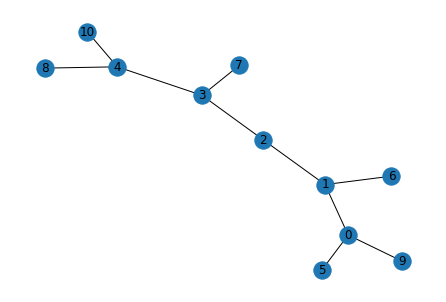

In [249]:
nx.draw(T1, with_labels=True)

We compute $m(G)$ and the dense vertices $V'$

In [250]:
m1 = get_m_degree(T1)
dense_vertices1 = get_dense_vertices(T1, m1)

Now, we check if it $T$ is pivoted. If $T$ is pivoted the function _is_pivoted_ will return the pivot.

In [263]:
v = is_pivoted(T1, dense_vertices1, m1)
v

2

Now that we know that 2 is the pivot of our tree we procceed to color $T$.

In [264]:
colors = color_pivoted_tree(T1, dense_vertices1, v, m1)
colors

{0: 3, 5: 2, 1: 2, 9: 4, 6: 3, 2: 4, 3: 2, 7: 3, 4: 4, 8: 2, 10: 3}

We now get random colors for our tree

In [265]:
colors_to_use = get_colors_to_use(T1, colors, m1-1)
colors_to_use

['#502D29',
 '#E7B86A',
 '#E7B86A',
 '#8E8A0F',
 '#502D29',
 '#8E8A0F',
 '#E7B86A',
 '#502D29',
 '#8E8A0F',
 '#E7B86A',
 '#502D29']

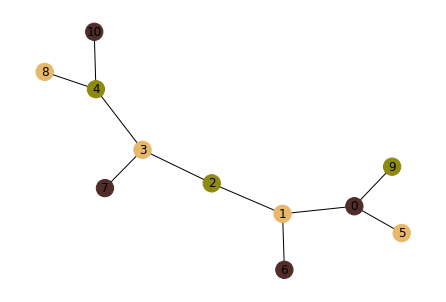

In [266]:
nx.draw(T1, with_labels=True, node_color=colors_to_use)

In [267]:
dense_vertices1

[3, 1, 0, 4]

In [271]:
b_chromatic_number = len(set(colors.values()))

In [272]:
check_b_chromatic_coloring(T1, dense_vertices1, colors, m1-1)

## Test 2: Coloring a non pivoted tree

In [273]:
edge_list2 = [('t','a'), ('a','s'), ('a','r'), ('a','b'), ('b','p'),('b','q'),('b','v'),('v','d'),('d','c'),('c','m'),('c','n'),
             ('c','o'),('d','e'),('e','k'),('e','j'),('e','l'), ('d','f'),('f','g'),('f','h'),('f','i')]
T2 = nx.Graph(edge_list2)

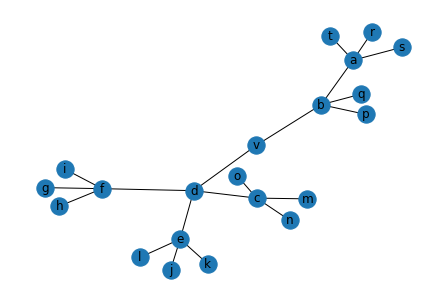

In [274]:
nx.draw(T2, with_labels=True)

In [275]:
m2 = get_m_degree(T2)
dense_vertices2 = get_dense_vertices(T2, m2)
dense_vertices2

['a', 'b', 'd', 'c', 'e', 'f']

Now we find a good set out of $V''$

In [276]:
W2 = good_set(T2, dense_vertices2, m2)
W2

['b', 'a', 'c', 'e', 'f']

Now we check if $W$ encircles a vertex in $V-W$

In [277]:
v_prime = does_encircle(T2, W2, m2)
v_prime

False

### Now that we have our good set we are going to color $T$

In [278]:
good_set_mask2 = {u:False for u in T2.nodes()}
for w in W2: good_set_mask2[w]=True
colors2 = color_non_pivoted_tree(T2, W2, good_set_mask2, m2)

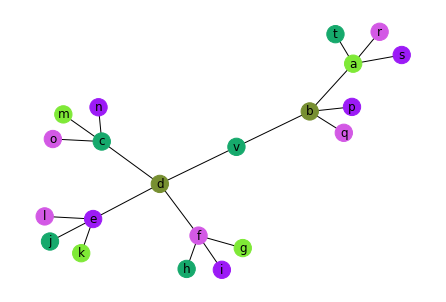

In [279]:
colors_to_use2 = get_colors_to_use(T2, colors2, m2)
nx.draw(T2, with_labels=True, node_color=colors_to_use2)

In [280]:
W2

['b', 'a', 'c', 'e', 'f']

In [281]:
len(set(colors2.values()))

5

In [282]:
check_b_chromatic_coloring(T2, W2, colors2, m2)

## Test 3: Coloring a non pivoted tree

In [283]:
edge_list3 = [(0,1), (0,2), (0,5), (1,3), (1,4), (1, 8), (2,11), (2, 12), (2,20), (4,21), (5,6), (5, 7), (5, 13), (5,18), (8, 9), (8, 10), (8,17), (8,19), 
              (11, 14), (11, 15), (11, 16), (21,22), (22,23), (22,24), (22,25), (22,26)]

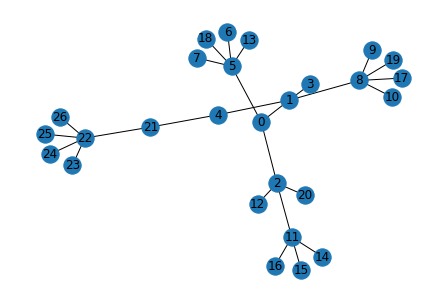

In [284]:
T3 = nx.Graph(edge_list3)
nx.draw(T3, with_labels=True)

First we get the degrees sorted, the $m$-degree and the dense vertices

In [285]:
m3 = get_m_degree(T3)
dense_vertices3 = get_dense_vertices(T3, m3)
print(m3)
dense_vertices3

5


[1, 2, 5, 8, 11, 22]

We take any subset of vertices of $V''\subseteq V'$ and build a good set out of it

In [286]:
W3 = good_set(T3, dense_vertices3, m3)
W3

[2, 5, 8, 11, 22]

In [287]:
good_set_mask3 = {w:False for w in T3.nodes()}
for w in W3: good_set_mask3[w] = True
colors3 = color_non_pivoted_tree(T3, W3, good_set_mask3, m3)

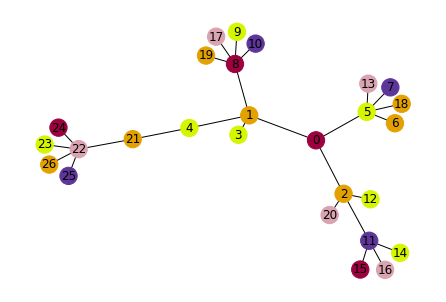

In [288]:
colors_to_use3 = get_colors_to_use(T3, colors3, m3)
nx.draw(T3, with_labels=True, node_color=colors_to_use3)

In [289]:
W3

[2, 5, 8, 11, 22]

In [290]:
len(set(colors3.values()))

5

In [291]:
check_b_chromatic_coloring(T3, W3, colors3, m3)

## Tests on random trees

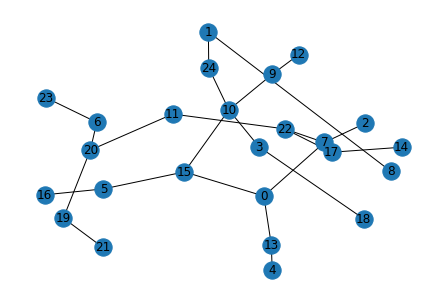

In [60]:
n = 25
Trand = random_mst_tree(n)
nx.draw(Trand, with_labels=True)

Computing the $m(G)$ and _dense_vertices_

In [61]:
#degrees_rand = get_sorted_degrees(Trand)
m_rand = get_m_degree(Trand)
V_rand = get_dense_vertices(Trand, m_rand)
m_rand, V_rand

(4, [0, 7, 10, 15, 20, 22])

__This graph only have isolated connected components__

In [62]:
pivot_rand = is_pivoted(Trand, V_rand, m_rand)
pivot_rand

False

Coloring a non pivoted Tree

First, we find a _good set_

In [63]:
Wrand = good_set(Trand, V_rand, m_rand)
Wrand

[0, 7, 10, 15]

Does the good set encircles some vertex in $T_{rand}$

In [64]:
does_encircle(Trand, Wrand, m_rand)

False

Now we will color the tree. We will construct a good set mask and the we will color the graph

In [65]:
good_set_mask_rand = {u:False for u in Trand.nodes()}
for w in Wrand: good_set_mask_rand[w]=True
colors_rand = color_non_pivoted_tree(Trand, Wrand, good_set_mask_rand, m_rand)

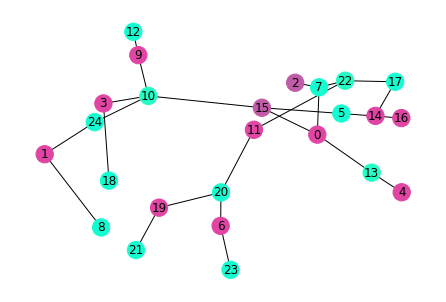

In [66]:
colors_to_use = get_colors_to_use(Trand, colors_rand, m_rand)
nx.draw(Trand, with_labels=True, node_color=colors_to_use)

In [67]:
Wrand

[0, 7, 10, 15]

In [68]:
check_b_chromatic_coloring(Trand, Wrand, colors_rand, m_rand)

## Measuring the value of $m$ in random trees

In [69]:
xs = [[1,2,3],[4,5,6]]
ys = [['a','b','c'],['f','g','h']]
zs = ['name1', 'name2']
for x, y, z in zip(xs, ys, zs):
    print(x,y, z)

[1, 2, 3] ['a', 'b', 'c'] name1
[4, 5, 6] ['f', 'g', 'h'] name2


In [43]:
def plot_lines(xs, ys, labels, x_label, y_label, name):
    fig, ax = plt.subplots(1)
    for x, y, l in zip(xs, ys, labels):
        x = np.array(x)
        y = np.array(y)
        ax.plot(x, y, label=l)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend()
    fig.savefig(name)
    
def scatter_plot(xs, ys, labels,  x_label, y_label, name):
    fig, ax = plt.subplots(1)
    for x, y, l in zip(xs,ys, labels):
        x = np.array(x)
        y = np.array(y)
        ax.scatter(x, y, label=l)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    fig.savefig(name)
    ax.legend()

In [1]:
def run_experiment(n_attempts, max_n_vertices, random_tree_f):
    n_vertices_list = [i for i in range(50, max_n_vertices, 50)]
    max_degree_avg_list = []
    m_degrees_values_avg = []
    number_dense_vertices_avg = []
    non_pivoted_counter_avg = []
    for n in n_vertices_list:
        m_degree_avg = 0
        dense_vertices_avg = 0
        non_pivoted_counter = 0
        max_degree_avg = 0
        for i in range(n_attempts):
            Ti = random_tree_f(n)
            mi = get_m_degree(Ti)
            max_degree_avg += max(dict(Ti.degree()).values())
            m_degree_avg += mi
            dense_vertices_i = get_dense_vertices(Ti, mi)
            dense_vertices_avg += len(dense_vertices_i)
            if not is_pivoted(Ti, dense_vertices_i, mi):
                non_pivoted_counter += 1
        m_degrees_values_avg.append(m_degree_avg/n_attempts)
        number_dense_vertices_avg.append(dense_vertices_avg/n_attempts)
        non_pivoted_counter_avg.append(non_pivoted_counter/n_attempts)
        max_degree_avg_list.append(max_degree_avg/n_attempts)
    return n_vertices_list, m_degrees_values_avg, number_dense_vertices_avg, non_pivoted_counter_avg, max_degree_avg_list

In [25]:
test1 = {}
test2 = {}
test3 = {}
test4 = {}

__Testing random recursive trees__

In [26]:
%%time
test1['n_vertices_list'], test1['m_degree_avgs'], test1['dense_vertices_avgs'], test1['non_pivoted_avgs'], test1['max_degree_avgs'] = run_experiment(50, 2050, random_recursive_tree)

CPU times: user 4.87 s, sys: 68.8 ms, total: 4.94 s
Wall time: 4.94 s


__Testing random MST trees__

In [81]:
%%time
test2['n_vertices_list'], test2['m_degree_avgs'], test2['dense_vertices_avgs'], test2['non_pivoted_avgs'], test2['max_degree_avgs'] = run_experiment(50, 2050, random_mst_tree)

KeyboardInterrupt: 

__Testing on random BFS trees__

In [33]:
%%time
test3['n_vertices_list'], test3['m_degree_avgs'], test3['dense_vertices_avgs'], test3['non_pivoted_avgs'], test3['max_degree_avgs'] = run_experiment(50, 2050, random_bfs_tree)

CPU times: user 1h 39min, sys: 58.4 s, total: 1h 39min 58s
Wall time: 2h 5min 17s


__Testing on random Pruffer sequence trees__

In [27]:
%%time
test4['n_vertices_list'], test4['m_degree_avgs'], test4['dense_vertices_avgs'], test4['non_pivoted_avgs'], test4['max_degree_avgs'] = run_experiment(50, 2050, nx.random_tree)

CPU times: user 5.95 s, sys: 45 ms, total: 6 s
Wall time: 6 s


In [28]:
tests_n_vertices_lists = [test1['n_vertices_list'], test4['n_vertices_list']]
tests_max_degree_lists = [test1['max_degree_avgs'], test4['max_degree_avgs']]
tests_m_degree_lists = [test1['m_degree_avgs'],  test4['m_degree_avgs']]
tests_dense_vertices_lists = [test1['dense_vertices_avgs'], test4['dense_vertices_avgs']]
tests_non_pivoted_avgs_lists = [test1['non_pivoted_avgs'],  test4['non_pivoted_avgs']]
labels = ['recursive trees','Pruffer trees']

__Average maximum degree against number of vertices__

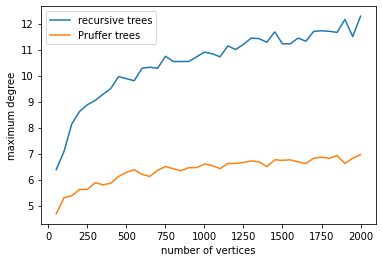

In [35]:
plot_lines(tests_n_vertices_lists, tests_max_degree_lists, labels, "number of vertices", "maximum degree")

__Average $m$-degree value against number of vertices__

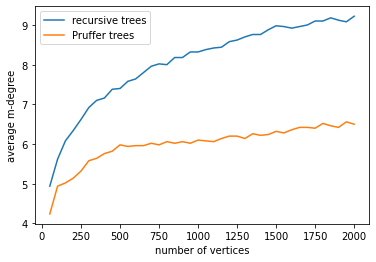

In [38]:
plot_lines(tests_n_vertices_lists, tests_m_degree_lists, labels, "number of vertices","average m-degree")

__Average number of dense vertices against number of vertices__

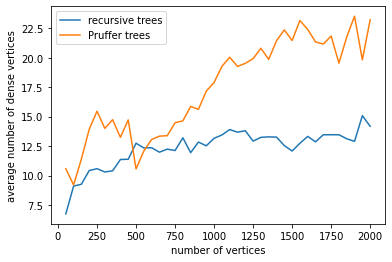

In [39]:
plot_lines(tests_n_vertices_lists, tests_dense_vertices_lists, labels, "number of vertices", "average number of dense vertices")

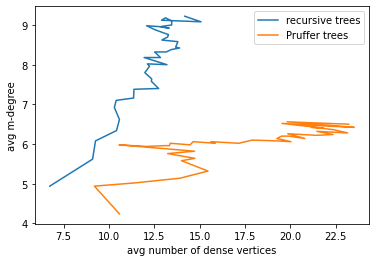

In [42]:
plot_lines(tests_dense_vertices_lists, tests_m_degree_lists, labels, "avg number of dense vertices", "avg m-degree", "plot 1")

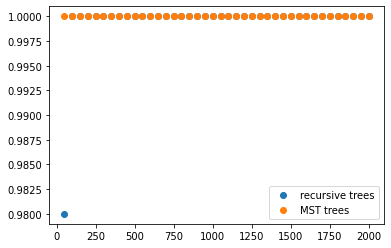

In [40]:
scatter_plot(tests_n_vertices_lists[:-2], tests_non_pivoted_avgs_lists[:-2], labels[:-2])

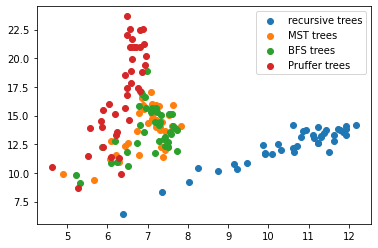

In [41]:
scatter_plot(tests_max_degree_lists, tests_dense_vertices_lists, labels)

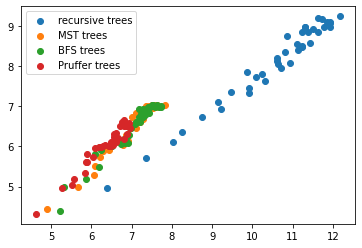

In [42]:
scatter_plot(tests_max_degree_lists, tests_m_degree_lists, labels)

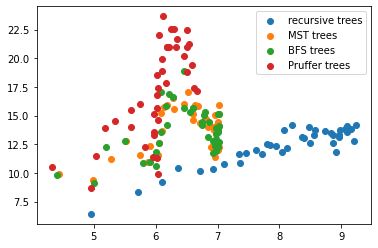

In [43]:
scatter_plot(tests_m_degree_lists, tests_dense_vertices_lists, labels)

### Coloring Random Trees

In [ ]:
n_vertices_min = 100
n_vertices_max = 1000
n_attempts = 1000
trees = []
colorings = []
m_degrees = []
for _ in range(n_attempts):
    n_vertices = random.randint(n_vertices_min, n_vertices_max)
    ran_node_degrees = build_random_tree_nodes(n_vertices)
    ran_edge_list = bfs_build_tree(ran_node_degrees)
    Ti = nx.Graph(ran_edge_list)
    trees.append(Ti)
    sorted_degrees_i = get_sorted_degrees(Ti)
    mi = get_m_degree(sorted_degrees_i)
    dense_vertices_i = get_dense_vertices(sorted_degrees_i, mi)
    vi = is_pivoted(Ti, dense_vertices_i, mi)
    if vi is False:
        #coloring a non pivoted tree
        Wi = good_set(Ti, dense_vertices_i, mi)
        good_set_mask_i = {u:False for u in Ti.nodes()}
        for w in Wi: good_set_mask_i[w]=True
        colors_i = color_non_pivoted_tree(Ti, Wi, good_set_mask_i, mi)
        colorings.append(colors_i)
        check_b_chromatic_coloring(Ti, Wi, colors_i, mi)
    else:
        #coloring a pivoted tree
        colors_i = color_pivoted_tree(Ti, dense_vertices_i, vi, mi)
        colorings.append(colors_i)
        check_b_chromatic_coloring(Ti, dense_vertices_i, colors_i, mi-1)

In [ ]:
Tprob = trees[-1]

In [ ]:
nx.draw(Tprob, with_labels=True)

In [ ]:
degrees_problem = get_sorted_degrees(Tprob)
m_degree_prob = get_m_degree(degrees_problem)
dense_vertices_prob = get_dense_vertices(degrees_problem, m_degree_prob)
m_degree_prob, dense_vertices_prob

In [ ]:
W_prob = good_set(Tprob, dense_vertices_prob, m_degree_prob)
W_prob

In [ ]:
good_set_mask_pro = {u:False for u in Tprob.nodes()}
for w in W_prob: good_set_mask_pro[w]=True
colors_prob = color_non_pivoted_tree(Tprob, W_prob, good_set_mask_pro, m_degree_prob)

In [ ]:
colors_to_use_prob = get_colors_to_use(Tprob, colors_prob, m_degree_prob)
nx.draw(Tprob, with_labels=True, node_color=colors_to_use_prob)

In [ ]:
check_b_chromatic_coloring(Tprob, W_prob, colors_prob, m_degree_prob)

Compare 4 different techniques for generating random trees:

1. Prufer sequence
2. BFS random trees
3. Random recursive
4. MST on graph

In [ ]:
edge_list_example = [(0,1),(0,2), (0,3), (1,7),(7,8), (7,9)]
Texample = nx.Graph(edge_list_example)
nx.draw(Texample, with_labels=True)

In [ ]:
sorted_degrees_example = get_sorted_degrees(Texample)
m_ex = get_m_degree(sorted_degrees_example)
dense_vertices_ex = get_dense_vertices(sorted_degrees_example, m_ex)
m_ex, dense_vertices_ex

In [ ]:
is_pivoted(Texample, dense_vertices_ex, m_ex)